I need to have a envinronment that given an action returns the state and reward.

In [1]:
import numpy as np
from itertools import product
import scipy.stats as stats
from tqdm import tqdm
import concurrent.futures
from functools import cache
from multiprocessing import Manager
import matplotlib.pyplot as plt

# Environment

In [2]:
class learning_environment:
    def __init__(self, debug = False):
        self.debug = debug
        self.logs = []

    def log(self, message):
        if self.debug:
            print(message)
        
        self.logs.append(message)

    def step(self, action: int):
        raise NotImplementedError
    
    def p(self, state: tuple[int], action: int, next_state: tuple[int]):
        raise NotImplementedError

In [3]:
class car_rental(learning_environment):
    def __init__(self, reward_per_car, cost_to_move_car, max_moving, locations: int, rental_requests, rental_returns, max_storage_of_locations, debug=False):

        super().__init__(debug)

        self.reward_per_car = reward_per_car
        self.cost_to_move_car = cost_to_move_car
        self.max_moving = max_moving
        self.locations = locations
        self.rental_requests = rental_requests
        self.rental_returns = rental_returns
        self.max_storage_of_locations = max_storage_of_locations

        if len(rental_requests) != locations or len(rental_returns) != locations:
            raise ValueError('The length of rental_requests and rental_returns should be equal to the number of locations')

        # Initialize the number of cars at each location to be max_storage_of_locations
        self.state = np.array([max_storage_of_locations for i in range(locations)])

        # Calculate all possible states and actions        
        self.states = list(product(range(self.max_storage_of_locations+1), repeat=locations))

        self.actions = {tuple(state): list(range(-min(state[1], max_moving, max_storage_of_locations-state[0]), min(state[0], max_moving, max_storage_of_locations-state[1]) + 1)) for state in self.states}
        self.all_possible_state_reward_tuples = list(product(self.states, range(0, (self.max_storage_of_locations*self.reward_per_car)+1)))

        # Precompute Poisson probabilities for rental requests and returns
        self.rental_request_probs = [
            {i: stats.poisson.pmf(i, self.rental_requests[location]) for i in range(self.max_storage_of_locations+1)}
            for location in range(locations)
        ]
        self.rental_return_probs = [
            {i: stats.poisson.pmf(i, self.rental_returns[location]) for i in range(self.max_storage_of_locations+1)}
            for location in range(locations)
        ]

    
    def __move_cars(self, state,action):
        # Move the cars from the previous nights
        if action > self.max_moving:
            raise ValueError('The number of cars moved should be less than or equal to the max_moving')
        
        if action > state[0]:
            raise ValueError('The number of cars moved should be less than or equal to the number of cars at the first location')
        
        if action < -state[1]:
            raise ValueError('The number of cars moved should be less than or equal to the number of cars at the second location')

        state[0] -= action
        state[1] = min(self.max_storage_of_locations, state[1] + action)

        reward = -action * self.cost_to_move_car

        return state, reward

    def step(self, action):
        '''
        Action should be the number of cars to move from the first location to the second location
        '''
        reward = 0

        new_state, moving_costs = self.__move_cars(self.state, action)

        self.state = new_state

        reward += moving_costs


        self.log(f"Overnight cars moved from location 1 to location 2: {action}")
        self.log(f"State at the start of the day: {self.state}")
        
        # Calculate the requests and returns

        location_requests = [np.random.poisson(self.rental_requests[i]) for i in range(self.locations)]
        location_returns = [np.random.poisson(self.rental_returns[i]) for i in range(self.locations)]

        self.log("Location requests: ", location_requests)
        self.log("Location returns: ", location_returns)
        for i in range(self.locations):
            rented_cars = min(location_requests[i], self.state[i])

            reward += rented_cars * self.reward_per_car

            self.state[i] -= rented_cars

            self.state[i] = min(self.max_storage_of_locations, self.state[i] + location_returns[i])
        
        self.log(f"Reward at the end of the day: {reward}")

        return self.state, reward

    def p(self, state, action, expected_state, expected_reward):
        '''
        The probability of the next state and reward given the current state and action
        '''

        reward = 0

        new_state, moving_costs = self.__move_cars(state, action)

        reward += moving_costs

        needed_reward = expected_reward - reward

        if needed_reward < 0:
            # It is impossible to get the needed reward
            return 0
        
        state_changes = expected_state[0]-new_state[0], expected_state[1]-new_state[1]

        self.log(f"After moving cars we need the locations to change by {state_changes} and get reward {needed_reward}")

        if needed_reward % self.reward_per_car != 0:
            self.log("The needed reward is not a multiple of the reward per car")
            return 0
        total_requests_needed = needed_reward // self.reward_per_car
        requests_options = [(i, total_requests_needed-i) for i in range(total_requests_needed+1) if (total_requests_needed-i <= state[1]) and (i <= state[0])]

        request_option_probs = []
        self.log(f"Possible request options (requests at location 1, requests at location 2): {requests_options}")
        for request_option in requests_options:
            state_change_prob = [0, 0]
            for location in range(self.locations):
                needed_returns = state_changes[location] + request_option[location]
                if needed_returns < 0:
                    request_option_probs.append(0)
                    break
                
                state_change_prob[location] = self.rental_request_probs[location][request_option[location]] * self.rental_return_probs[location][needed_returns]
        
            request_option_probs.append(state_change_prob[0] * state_change_prob[1])

        self.log(f"Probabilities of the different request options: {request_option_probs}")

        return sum(request_option_probs)
        
    def get_states(self):
        return self.states
    def get_actions(self, state):
        return self.actions[state]
    def get_all_possible_state_reward_tuples(self):
        return self.all_possible_state_reward_tuples

# Learner

In [4]:
class policy_iteration_learner:
    def __init__(self, env: learning_environment, discount_factor=0.9, theta=0.01):
        self.env = env
        self.discount_factor = discount_factor
        self.theta = theta

        self.policy = {state: 0 for state in env.get_states()}
        self.value_function = {state: 0 for state in env.get_states()}
        self.p_cache = {}

    def __get_p(self, state, action, next_state, reward):
        if (state, action, next_state, reward) in self.p_cache:
            return self.p_cache[(state, action, next_state, reward)]
        
        p = self.env.p(list(state), action, next_state, reward)
        self.p_cache[(state, action, next_state, reward)] = p

        return p
    
    def calculate_sum_possible_next_states(self, state, action):
        '''
        This implements the bellmans backup equation.  
        sum of p(s', r|s, a) * (r + gamma * V(s')) over all s' and r
        '''
        # Calculate the probabilities and values
        probabilities = np.array([self.__get_p(state, action, ns, reward) for ns, reward in self.env.get_all_possible_state_reward_tuples()])
        values = self.discount_factor * np.array([self.value_function[ns] for ns, _ in self.env.get_all_possible_state_reward_tuples()])
        
        # Sum the result
        return np.sum(probabilities * (np.array([reward for _, reward in self.env.get_all_possible_state_reward_tuples()]) + values))
        # return sum(
        #     [self.__get_p(state, action, next_state, reward) * (reward + self.discount_factor * self.value_function[next_state]) for next_state, reward in self.env.get_all_possible_state_reward_tuples()]
        # )

    def update_value_function(self, state, action, value_function):

        old_value = value_function[state]
        value_function[state] = self.calculate_sum_possible_next_states(state, action)
        delta = abs(old_value - value_function[state])

        return delta

    def policy_evaluation(self):
        with Manager() as manager:
            while True:
                shared_value_function = manager.dict(self.value_function)
                deltas = []
                with concurrent.futures.ProcessPoolExecutor() as executor:
                    futures = {executor.submit(self.update_value_function, state, self.policy[state], shared_value_function): state for state in self.env.get_states()}
                    for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Policy evaluation"):
                        deltas.append(future.result())

                delta = max(deltas)
                print(f" Delta: {delta}")
                if delta < self.theta:
                    break
                self.value_function = dict(shared_value_function)

    def get_new_policy(self, state):
        action_values = [
            self.calculate_sum_possible_next_states(state, action)
            for action in self.env.get_actions(state)
        ]

        return state, self.env.get_actions(state)[np.argmax(action_values)]

    def policy_improvement(self):
        policy_stable = True
        with concurrent.futures.ProcessPoolExecutor() as executor:
            futures = {executor.submit(self.get_new_policy, state): state for state in self.env.get_states()}
            for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures), desc="Policy improvement"):
                state, new_action = future.result()
                old_action = self.policy[state]
                self.policy[state] = new_action
                if old_action != self.policy[state]:
                    policy_stable = False
        
        return policy_stable
    
    def policy_iteration(self):

        while True:
            self.policy_evaluation()
            policy_stable = self.policy_improvement()

            if policy_stable:
                break

        return self.policy, self.value_function

# Execution

In [5]:
max_moving = 5
max_storage_of_locations = 20

In [6]:
rental_problem = car_rental(10, 2, max_moving, 2, [3,4], [3,2], max_storage_of_locations, False)

rental_problem.p([20, 20], 2, (18, 18), 30+40 - 4)


0.005979579483683183

In [7]:
first_full_runthrough = pickle.load(open('learner.pkl', 'rb'))
first_full_runthrough.value_function


NameError: name 'pickle' is not defined

In [ ]:
import pickle
pickle.dump(learner, open('late_night_learner.pkl', 'wb'))

In [8]:
learner = policy_iteration_learner(rental_problem, theta=0.1)

learner.policy_evaluation()
# learner.policy_iteration()

Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 14.93it/s]


 Delta: 69.96887662685617


Policy evaluation: 100%|██████████| 441/441 [00:28<00:00, 15.29it/s]

 Delta: 62.062852807920024



Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 15.14it/s]


...

 Delta: 0.18666105929855803


Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 14.89it/s]


 Delta: 0.10732196577100694


Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 14.89it/s]


 Delta: 0.06142323796717619


In [21]:
learner.policy_evaluation()

Policy evaluation: 100%|██████████| 441/441 [00:30<00:00, 14.37it/s]


 Delta: 13.673577502527621


Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 15.05it/s]

 Delta: 5.022429242960982



Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 14.99it/s]


...

 Delta: 0.13602320776431043


Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 14.95it/s]


 Delta: 0.10043638064058769


Policy evaluation: 100%|██████████| 441/441 [00:29<00:00, 14.99it/s]


 Delta: 0.07388708416419831


In [23]:
learner.policy_improvement()

Policy improvement: 100%|██████████| 441/441 [03:47<00:00,  1.94it/s]


False

In [25]:
learner.policy

{(0, 0): 0,
 (0, 1): 0,
 (0, 2): -1,
 (0, 3): -1,
 (0, 4): -2,
 (0, 5): -2,
 (0, 6): -3,
 (0, 7): -3,
 (0, 8): -4,
 (0, 9): -4,
 (0, 10): -5,
 (0, 11): -5,
 (0, 12): -5,
 (0, 13): -5,
 (0, 14): -5,
 (0, 15): -5,
 (0, 16): -5,
 (0, 17): -5,
 (0, 18): -5,
 (0, 19): -5,
 (0, 20): -5,
 (1, 0): 0,
 (1, 1): 0,
 (1, 2): 0,
 (1, 3): -1,
 (1, 4): -1,
 (1, 5): -2,
 (1, 6): -2,
 (1, 7): -3,
 (1, 8): -3,
 (1, 9): -4,
 (1, 10): -4,
 (1, 11): -4,
 (1, 12): -5,
 (1, 13): -5,
 (1, 14): -5,
 (1, 15): -5,
 (1, 16): -5,
 (1, 17): -5,
 (1, 18): -5,
 (1, 19): -5,
 (1, 20): -5,
 (2, 0): 1,
 (2, 1): 1,
 (2, 2): 0,
 (2, 3): 0,
 (2, 4): -1,
 (2, 5): -1,
 (2, 6): -2,
 (2, 7): -2,
 (2, 8): -3,
 (2, 9): -3,
 (2, 10): -3,
 (2, 11): -4,
 (2, 12): -4,
 (2, 13): -5,
 (2, 14): -5,
 (2, 15): -5,
 (2, 16): -5,
 (2, 17): -5,
 (2, 18): -5,
 (2, 19): -5,
 (2, 20): -5,
 (3, 0): 2,
 (3, 1): 1,
 (3, 2): 1,
 (3, 3): 0,
 (3, 4): 0,
 (3, 5): -1,
 (3, 6): -1,
 (3, 7): -2,
 (3, 8): -2,
 (3, 9): -2,
 (3, 10): -3,
 (3, 11): -3,
 (3,

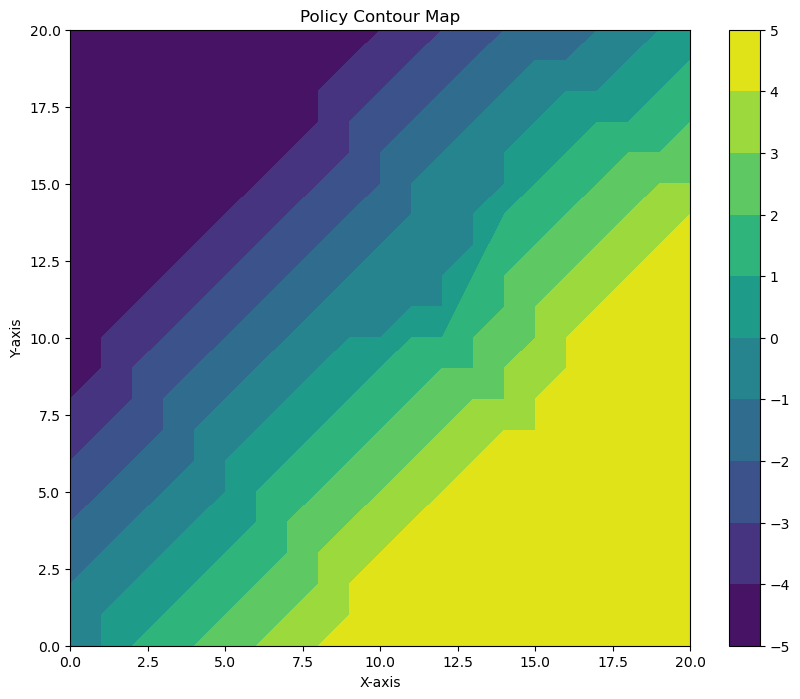

In [24]:
plot_policy(learner.policy)

In [11]:

def plot_policy(learner_policy):
    # Create an empty 2D array and fill it with the policy values
    policy = np.zeros((21,21))
    for (x, y), value in learner_policy.items():
        policy[x, y] = value

    # Create a meshgrid for plotting
    x = np.arange(policy.shape[0])
    y = np.arange(policy.shape[1])
    X, Y = np.meshgrid(x, y)

    # Define the discrete color levels
    levels = np.arange(-5, 6, 1)

    # Create the contour plot with discrete color steps
    plt.figure(figsize=(10, 8))
    contour = plt.contourf(X, Y, policy.T, levels=levels, cmap='viridis')
    plt.colorbar(contour, ticks=levels)
    plt.title('Policy Contour Map')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

After spending a day or two on this code trying to do two things. Speed it up and debug the learner I have decieded to move on.

I have created a first_full_runthrough.pkl file which has my policy that isn't crazy but isnt the opitmal policy.

I will quickly implement the extended version of the rental car problem. 

# Modified car rental

This involves having overflwo charges and the first move from locatoin 1 to 2 is free.

I think that this will be a good example from my perspective to see that implementing this is trivial as the algorithm can handle this without problem.

In [28]:
class modified_car_rental(car_rental):
    def __init__(self, reward_per_car, cost_to_move_car, max_moving, locations: int, rental_requests, rental_returns, max_storage_of_locations, debug=False):

        super().__init__(reward_per_car, cost_to_move_car, max_moving, locations, rental_requests, rental_returns, max_storage_of_locations, debug)

        self.overflow_threshold = 10
        self.overflow_cost = 4

        self.free_transfers_from_1_to_2 = 1
        self.free_transfers_from_2_to_1 = 0

    def __move_cars(self, state, action):
        new_state, initial_reward = super().__move_cars(state, action)

        if action > 0:
            initial_reward += min(action,self.free_transfers_from_1_to_2) * self.cost_to_move_car

        if action < 0:
            initial_reward += min(-action,self.free_transfers_from_2_to_1) * self.cost_to_move_car

        if new_state[0] > self.overflow_threshold:
            initial_reward -= self.overflow_cost

        if new_state[1] > self.overflow_threshold:
            initial_reward -= self.overflow_cost
    
        return new_state, initial_reward

In [29]:
modified_learner = policy_iteration_learner(modified_car_rental(10, 2, 5, 2, [3,4], [3,2], 20, False), theta=0.1)

modified_learner.policy_evaluation()

Policy evaluation: 100%|██████████| 441/441 [00:39<00:00, 11.22it/s]

 Delta: 0
